In [14]:
# ================================================
# Binary Solar Panel Fault Classifier - MobileNetV3
# ================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import json
from pathlib import Path

print("✅ All libraries imported successfully!\n")

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
SEED = 42
FREEZE_EPOCHS = 5

CLASS_NAMES = ["Healthy", "Anomaly"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Device being used: {device}")
print(f"📊 Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🕒 Total epochs: {NUM_EPOCHS} (including {FREEZE_EPOCHS} warmup epochs)\n")

torch.manual_seed(SEED)
np.random.seed(SEED)

✅ All libraries imported successfully!

🔥 Device being used: cuda
📊 Image size: 224x224
📦 Batch size: 32
🕒 Total epochs: 50 (including 5 warmup epochs)



In [15]:
print("🔧 Creating Binary Remapped Dataset with 3 imbalance strategies...\n")

BINARY_MAP = {
    "Class_0_Clean_panels": 0,
    "Class_1_Soiling_pollution": 1,
    "Class_2_Shadowing_vegetation": 1,
    "Class_3_Burn_Discoloration": 1,
    "Class_4_Structural_damage": 1,
}

class BinaryRemappedDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)
        self.binary_remap = {idx: BINARY_MAP[name] for name, idx in self.class_to_idx.items()}
        self.targets = [self.binary_remap[label] for label in self.targets]
        self.imgs = [(path, self.binary_remap[label]) for path, label in self.imgs]

    def __getitem__(self, index):
        img, _ = super().__getitem__(index)
        return img, self.targets[index]


def build_binary_dataloaders(data_dir):
    print(f"📂 Loading dataset from: {data_dir}")
    
    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    full_dataset = BinaryRemappedDataset(data_dir, transform=None)
    print(f"✅ Dataset loaded successfully! Total images: {len(full_dataset)}")
    
    # Split
    indices = list(range(len(full_dataset)))
    labels = full_dataset.targets
    
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=SEED)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, 
                                         stratify=[labels[i] for i in temp_idx], random_state=SEED)

    train_dataset = Subset(full_dataset, train_idx)
    val_dataset   = Subset(full_dataset, val_idx)
    test_dataset  = Subset(full_dataset, test_idx)

    train_dataset.dataset.transform = train_tf
    val_dataset.dataset.transform   = val_tf
    test_dataset.dataset.transform  = val_tf

    # Weighted Sampler (Strategy 2)
    train_labels = [full_dataset.targets[i] for i in train_idx]
    class_counts = np.bincount(train_labels)
    sample_weights = [1.0 / class_counts[l] for l in train_labels]

    sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights), 
                                    num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True)
    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    # Weighted Loss (Strategy 3)
    total = len(train_labels)
    loss_weights = torch.tensor([total / (2 * c) for c in class_counts], dtype=torch.float32).to(device)

    print(f"📊 Final splits → Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
    print(f"   Healthy: {class_counts[0]:4d} images")
    print(f"   Anomaly: {class_counts[1]:4d} images")
    print(f"⚖️  Loss weights → Healthy: {loss_weights[0]:.3f} | Anomaly: {loss_weights[1]:.3f}")

    return train_loader, val_loader, test_loader, loss_weights


print("✅ Binary dataset class and dataloader function created successfully!")

🔧 Creating Binary Remapped Dataset with 3 imbalance strategies...

✅ Binary dataset class and dataloader function created successfully!


In [16]:
print("🏗️  Defining model, training and evaluation functions...\n")

def build_mobilenetv3(num_classes=2):
    print("   Loading pre-trained MobileNetV3-Small...")
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    print("   ✅ MobileNetV3-Small model ready with new classifier head")
    return model


def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=scaler is not None):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_probs, all_labels = [], [], []
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return (running_loss / total, correct / total, 
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, train_loader, val_loader, criterion, save_dir):
    print("🚀 Starting full fine-tuning...")
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None
    
    best_f1 = 0.0
    best_weights = None
    
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, preds, probs, labels = evaluate(model, val_loader, criterion)
        val_f1 = f1_score(labels, preds, average='macro')
        
        scheduler.step()
        
        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {val_f1:.4f} "
              f"[{time.time()-t0:.1f}s]")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_dir / "best_model.pt")
            print(f"   → New best validation F1: {best_f1:.4f} (model saved)")

    model.load_state_dict(best_weights)
    print(f"\n✅ Training finished! Best Val F1 = {best_f1:.4f}")
    return model


print("✅ All training functions defined successfully!")

🏗️  Defining model, training and evaluation functions...

✅ All training functions defined successfully!


In [17]:
# ====================== TRAINING ======================

print("🚀 Starting the full training pipeline...\n")

data_dir = "/kaggle/input/datasets/chellalaicha/unified-solar-panel-dataset/unified_dataset_augmented" 

save_dir = Path("/kaggle/working/binary_results_mobilenet")
save_dir.mkdir(parents=True, exist_ok=True)

# Build dataloaders
train_loader, val_loader, test_loader, loss_weights = build_binary_dataloaders(data_dir)

criterion = nn.CrossEntropyLoss(weight=loss_weights)

# Build and train model
model = build_mobilenetv3(num_classes=2).to(device)

# Warm-up phase
print("\n🔥 Phase 1: Warm-up with frozen backbone...")
for param in model.features.parameters():
    param.requires_grad = False

optimizer_warm = optim.AdamW(model.classifier.parameters(), lr=LR*10)
scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

for ep in range(FREEZE_EPOCHS):
    loss, acc = train_one_epoch(model, train_loader, criterion, optimizer_warm, scaler)
    print(f"   Warmup {ep+1}/{FREEZE_EPOCHS} → Loss: {loss:.4f} | Acc: {acc:.4f}")

# Full fine-tuning
print("\n🔥 Phase 2: Full fine-tuning (all layers unfrozen)...")
for param in model.parameters():
    param.requires_grad = True

model = train_model(model, train_loader, val_loader, criterion, save_dir)

print("\n🎉 All training phases completed!")

🚀 Starting the full training pipeline...

📂 Loading dataset from: /kaggle/input/datasets/chellalaicha/unified-solar-panel-dataset/unified_dataset_augmented
✅ Dataset loaded successfully! Total images: 11600
📊 Final splits → Train: 8120 | Val: 1740 | Test: 1740
   Healthy: 1750 images
   Anomaly: 6370 images
⚖️  Loss weights → Healthy: 2.320 | Anomaly: 0.637
   Loading pre-trained MobileNetV3-Small...
   ✅ MobileNetV3-Small model ready with new classifier head

🔥 Phase 1: Warm-up with frozen backbone...
   Warmup 1/5 → Loss: 0.2828 | Acc: 0.8156
   Warmup 2/5 → Loss: 0.2006 | Acc: 0.8792
   Warmup 3/5 → Loss: 0.1573 | Acc: 0.9022
   Warmup 4/5 → Loss: 0.1315 | Acc: 0.9224
   Warmup 5/5 → Loss: 0.1143 | Acc: 0.9339

🔥 Phase 2: Full fine-tuning (all layers unfrozen)...
🚀 Starting full fine-tuning...
Epoch 01/50 | Train Loss: 0.0850 Acc: 0.9522 | Val Loss: 0.2024 Acc: 0.9178 F1: 0.8886 [14.6s]
   → New best validation F1: 0.8886 (model saved)
Epoch 02/50 | Train Loss: 0.0694 Acc: 0.9600 | 

📊 Running final evaluation on Test set...

FINAL TEST RESULTS
✅ Accuracy  : 0.9592
✅ Macro F1  : 0.9409
✅ ROC-AUC   : 0.9844

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8838    0.9333    0.9079       375
     Anomaly     0.9814    0.9663    0.9738      1365

    accuracy                         0.9592      1740
   macro avg     0.9326    0.9498    0.9409      1740
weighted avg     0.9604    0.9592    0.9596      1740



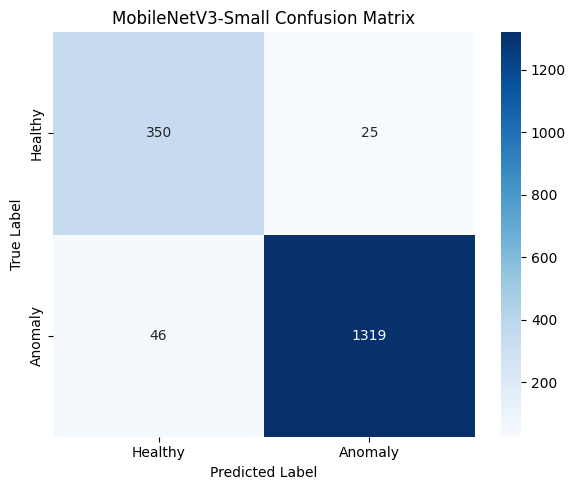


💾 Results and best model saved in: /kaggle/working/binary_results_mobilenet
   Files saved:
     • best_model.pt
     • confusion_matrix.png
     • final_results.json


In [18]:
print("📊 Running final evaluation on Test set...\n")

test_loss, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion)

test_f1 = f1_score(labels, preds, average='macro')
test_auc = roc_auc_score(labels, probs)

print("="*70)
print("FINAL TEST RESULTS")
print("="*70)
print(f"✅ Accuracy  : {test_acc:.4f}")
print(f"✅ Macro F1  : {test_f1:.4f}")
print(f"✅ ROC-AUC   : {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MobileNetV3-Small Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(save_dir / "confusion_matrix.png", dpi=200)
plt.show()

# Save summary
results = {
    "accuracy": float(test_acc),
    "f1": float(test_f1),
    "auc": float(test_auc),
    "epochs": NUM_EPOCHS
}

with open(save_dir / "final_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n💾 Results and best model saved in: {save_dir}")
print("   Files saved:")
print("     • best_model.pt")
print("     • confusion_matrix.png")
print("     • final_results.json")